# 6b. Partial Dependence Plot (PDP) — Explicabilité globale

Complément au notebook `06_explainability.ipynb` couvrant l'étape **7.1** du cahier des charges :
**SHAP summary plot, feature importance globale, Partial Dependence Plot (PDP)**.

Les PDP montrent l'effet marginal d'une feature sur la prédiction du modèle, en moyennant l'effet des autres variables. Appliqué ici aux **features linguistiques** numériques (longueur, ponctuation, hashtags, etc.) avec un Random Forest entraîné dessus.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay

FEATURE_COLS = [
    'word_count', 'char_count', 'avg_word_length', 'unique_word_count',
    'unique_word_ratio', 'exclamation_count', 'question_count',
    'uppercase_ratio', 'punctuation_count', 'hashtag_count',
    'mention_count', 'url_count'
]

train_df = pd.read_csv('../data/processed/train_processed.csv')
test_df  = pd.read_csv('../data/processed/test_processed.csv')

X_train = train_df[FEATURE_COLS].values
y_train = train_df['label_encoded'].values
X_test  = test_df[FEATURE_COLS].values
y_test  = test_df['label_encoded'].values

rf = RandomForestClassifier(n_estimators=200, max_depth=12,
                            random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print(f'RF accuracy (test, features linguistiques): {rf.score(X_test, y_test):.4f}')

RF accuracy (test, features linguistiques): 0.8593


## PDP 1D — Top-6 features

Top features: ['char_count', 'punctuation_count', 'word_count', 'unique_word_count', 'url_count', 'hashtag_count']


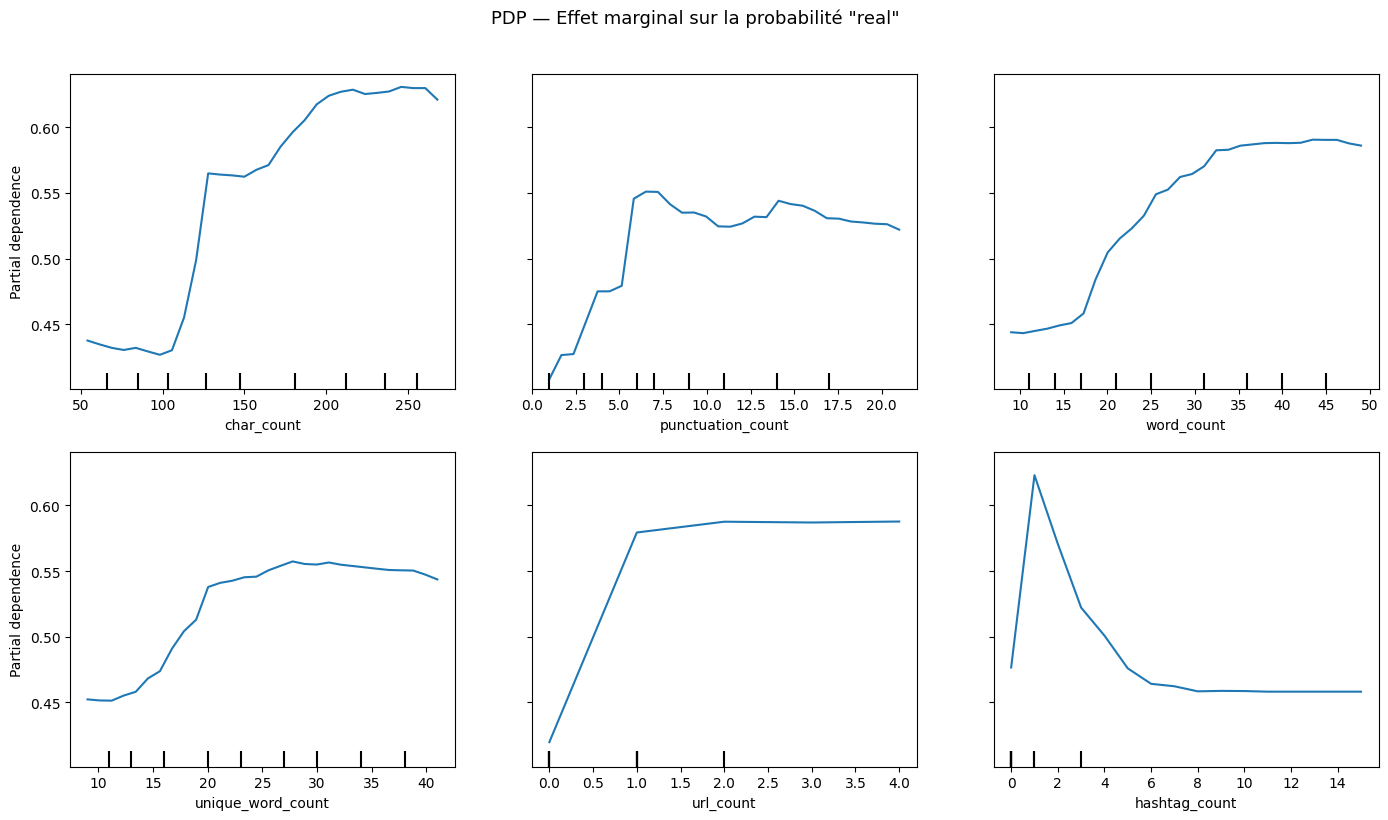

In [2]:
fi = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
top6 = fi.head(6).index.tolist()
print('Top features:', top6)

fig, ax = plt.subplots(figsize=(14, 8))
PartialDependenceDisplay.from_estimator(
    rf, X_train, features=top6, feature_names=FEATURE_COLS,
    ax=ax, n_cols=3, grid_resolution=30, target=1)
plt.suptitle('PDP — Effet marginal sur la probabilité "real"', y=1.02, fontsize=13)
plt.tight_layout()
os.makedirs('../reports/figures', exist_ok=True)
plt.savefig('../reports/figures/18_partial_dependence.png', dpi=120, bbox_inches='tight')
plt.show()

## PDP 2D — Interaction entre les 2 features les plus importantes

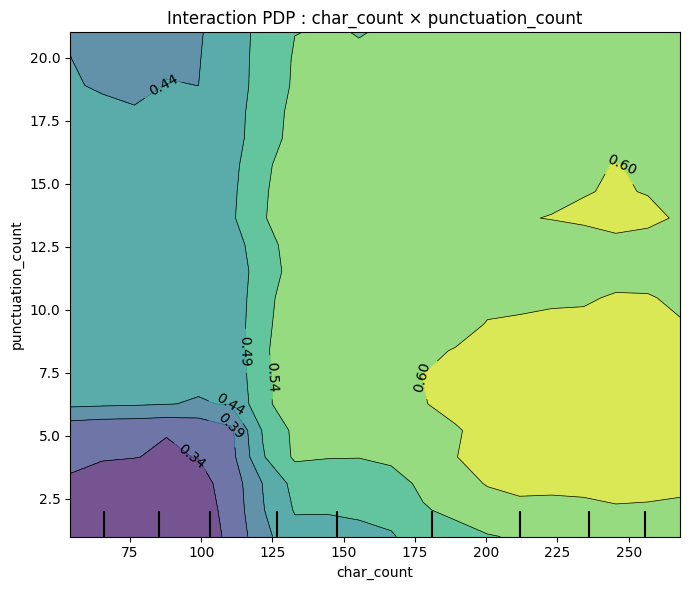

In [3]:
fig, ax = plt.subplots(figsize=(7, 6))
PartialDependenceDisplay.from_estimator(
    rf, X_train, features=[(top6[0], top6[1])],
    feature_names=FEATURE_COLS, ax=ax, grid_resolution=20, target=1)
plt.title(f'Interaction PDP : {top6[0]} \u00d7 {top6[1]}')
plt.tight_layout()
plt.savefig('../reports/figures/19_pdp_interaction.png', dpi=120, bbox_inches='tight')
plt.show()

## Lecture des PDP

- Une courbe **croissante** indique que l'augmentation de la feature pousse la prédiction vers `real` (label 1).
- Une courbe **plate** signifie que la feature n'a pas d'effet marginal global.
- Le PDP 2D révèle les **interactions** non linéaires entre deux features.

Cette analyse complète SHAP (importance globale + locale) en montrant explicitement la *forme* de l'effet de chaque feature.